# Gradient Descent in Linear Regression
We already know from the last laboratory the _Linear Regression_ finds the best-fit line for a dataset by minimizing the error between the actual and predicted values.

Now for the Gradinet Descent there are tow main methods of calculating the weights.
1. Stochastic GD (SGD) -  it updates weights after every single training example, where $ err = y_i - y_c $ and the new weight is $ w' = w - \eta \cdot err \cdot x_i $
2. Batch GD this updates weights once per epoch using the average gradient over all samples.
$$ J(w_j, b) = \frac{1}{n} \sum_{i = 1}^{n}{(y_i - (w_j \cdot x_i + b))^2} $$
$$ w_j = w_j - \eta \cdot \frac{\partial J}{\partial w_j} $$

In this process it's very important to chose a good learning rate. If $ \eta $ is to large we can overshoot the minimum and diverge, if it's to small it converges way to slow, on avrage it's _0.01_ or _0.001_.

---

### First task: What makes people happy? (using BGD)
For this will use two features, thouse being _GDB_ and _Freedom_. We will be using the data from the [World Happiness Report](https://worldhappiness.report/ed/2017/). The target variable will be _Happiness Score_.

In the end our function will look like this: $ Happiness Score = w_0 + w_1 \cdot GDB + w_2 \cdot Freedom $

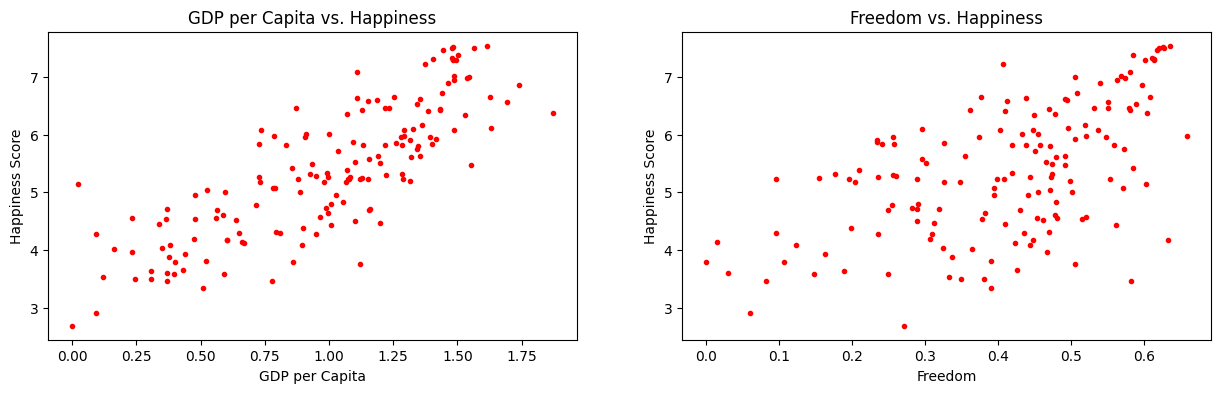

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('data/world-happiness-report-2017.csv')
features_names = ['Economy..GDP.per.Capita.', 'Freedom']
target_name = 'Happiness.Score'

fig, axes = plt.subplots(1,2, figsize=(15, 4))
for ax, feature, label in zip(axes, features_names, ['GDP per Capita', 'Freedom']):
    ax.plot(df[feature], df[target_name], 'ro', markersize=3)
    ax.set_xlabel(label)
    ax.set_ylabel('Happiness Score')
    ax.set_title(f'{label} vs. Happiness')

Before we start with the implementation, we need to normalize our data, this is important because it helps the gradient descent to converge faster. We will use min-max normalization for this. We will keep the original values of the features in case we want to use them later for prediction.

In [2]:
def min_max_normalization(df, column_name):
    min_val = min(df[column_name])
    max_val = max(df[column_name])
    if min_val == max_val:
        print(f'Warning: column {column_name} has zero variance, skipping normalization.')
        df[column_name + "_normalized"] = df[column_name]
        return
    df[column_name + "_normalized"] = [(val - min_val) / (max_val - min_val) for val in df[column_name]]
    return min_val, max_val

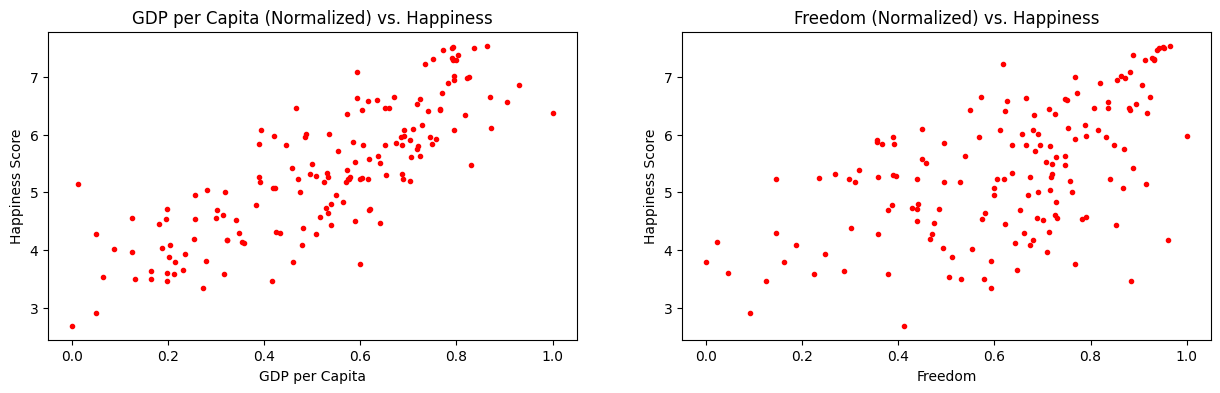

In [3]:
for feature in features_names:
	min_max_normalization(df, feature)

fig, axes = plt.subplots(1,2, figsize=(15, 4))
for ax, feature, label in zip(axes, features_names, ['GDP per Capita', 'Freedom']):
    ax.plot(df[feature + "_normalized"], df[target_name], 'ro', markersize=3)
    ax.set_xlabel(label)
    ax.set_ylabel('Happiness Score')
    ax.set_title(f'{label} (Normalized) vs. Happiness')

### Train Test Spliter
We've seen in the last laboratory that we need to split our data set into a training set and a test set. The training set is used to train the model, while the test set is used to evaluate the performance of the model. We will use the `train_test_split` function from the `sklearn` library to split our data set into a training set and a test set. We will use 80% of the data for training and 20% for testing.

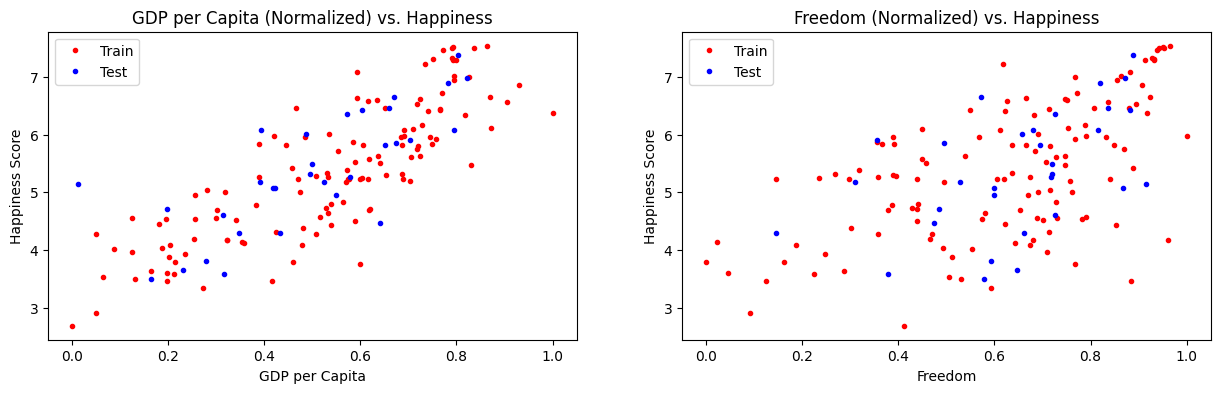

In [4]:
from sklearn.model_selection import train_test_split

X = df[[feature + "_normalized" for feature in features_names]]
Y = df[target_name]

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=1)

# now we will plot the training and test sets
fig, axes = plt.subplots(1,2, figsize=(15, 4))
for ax, feature, label in zip(axes, features_names, ['GDP per Capita', 'Freedom']):
	ax.plot(X_train[feature + "_normalized"], Y_train, 'ro', markersize=3, label='Train')
	ax.plot(X_test[feature + "_normalized"], Y_test, 'bo', markersize=3, label='Test')
	ax.set_xlabel(label)
	ax.set_ylabel('Happiness Score')
	ax.set_title(f'{label} (Normalized) vs. Happiness')
	ax.legend()

### Train the model
Now we can start with the implementation of the gradient descent algorithm. We will use the batch gradient descent for this. We will initialize the weights to zero and then we will update the weights using the formula mentioned above. We will repeat this process until we reach a certain number of iterations or until the cost function converges.

Learned weights: w0 = 3.0688, w1 = 2.0226, w2 = 1.9832
f(GDP, Freedom) = 3.0688 + 2.0226 * GDP + 1.9832 * Freedom
Cost on training set: 0.6797


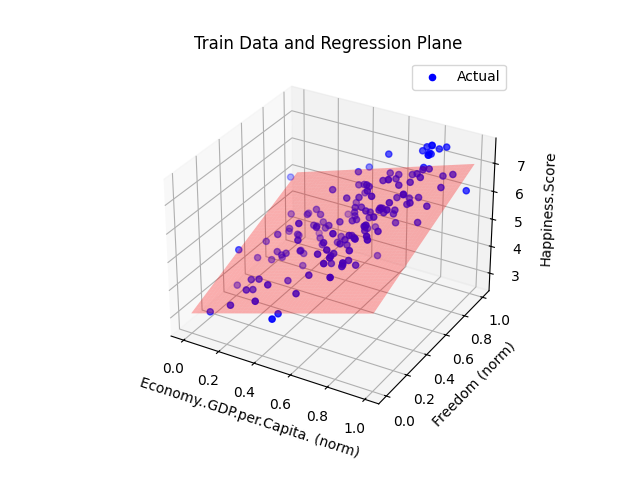

In [5]:
from sklearn.linear_model import SGDRegressor

model = SGDRegressor()
model.fit(X_train, Y_train)

w0 = model.intercept_[0]
w1, w2 = model.coef_

%matplotlib widget  

print(f'Learned weights: w0 = {w0:.4f}, w1 = {w1:.4f}, w2 = {w2:.4f}')
print(f'f(GDP, Freedom) = {w0:.4f} + {w1:.4f} * GDP + {w2:.4f} * Freedom')
print(f'Cost on training set: {model.score(X_train, Y_train):.4f}')

x1_range = np.linspace(df[features_names[0] + "_normalized"].min(), df[features_names[0] + "_normalized"].max(), 50)
x2_range = np.linspace(df[features_names[1] + "_normalized"].min(), df[features_names[1] + "_normalized"].max(), 50)
x1_grid, x2_grid = np.meshgrid(x1_range, x2_range)
y_grid = w0 + w1 * x1_grid + w2 * x2_grid

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(df[features_names[0] + "_normalized"], df[features_names[1] + "_normalized"], df[target_name], c='b', marker='o', label='Actual')
ax.plot_surface(x1_grid, x2_grid, y_grid, alpha=0.3, color='red')
ax.set_xlabel(f'{features_names[0]} (norm)')
ax.set_ylabel(f'{features_names[1]} (norm)')
ax.set_zlabel(target_name)
ax.set_title('Train Data and Regression Plane')
ax.legend()
plt.show()

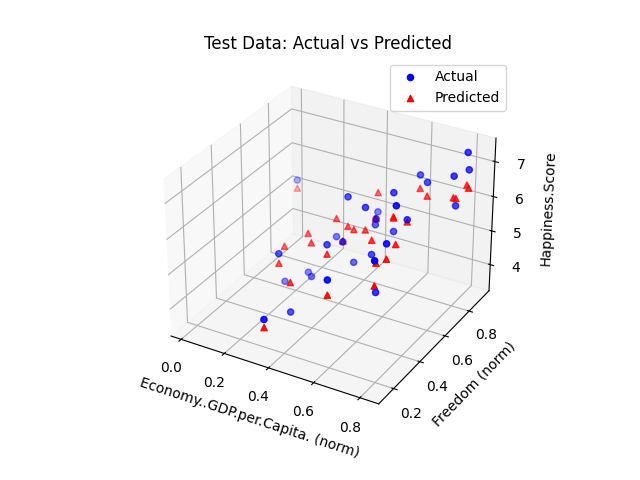

In [6]:
predictions = model.predict(X_test)
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_test[features_names[0] + "_normalized"], X_test[features_names[1] + "_normalized"], Y_test, c='b', marker='o', label='Actual')
ax.scatter(X_test[features_names[0] + "_normalized"], X_test[features_names[1] + "_normalized"], predictions, c='r', marker='^', label='Predicted')
ax.set_xlabel(f'{features_names[0]} (norm)')
ax.set_ylabel(f'{features_names[1]} (norm)')
ax.set_zlabel(target_name)
ax.set_title('Test Data: Actual vs Predicted')
ax.legend()
plt.show()

In [7]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
mae = mean_absolute_error(Y_test, predictions)
mse = mean_squared_error(Y_test, predictions)
print(f'Mean Absolute Error: {mae:.4f}')
print(f'Mean Squared Error: {mse:.4f}')

Mean Absolute Error: 0.5491
Mean Squared Error: 0.4072


### Gradient Descent from Scratch
Now that we have seen how we can use `sklearn` to train some data and then make presictions, let's see how we can implement our own gradient descent algorithm from scratch.

How we will do this is by first initializing the weights to zero, then we will calculate the predictions using the current weights, then we will calculate the error and update the weights using the formula mentioned above. We will repeat this process until we reach a certain number of iterations or until the cost function converges.

---

In the code below we first computer all the predictions $ y_c = w_0 + w_1 \cdot x_1 + w_2 \cdot x_2 $ then we compute the error $ err = y_i - y_c $ and then we update the weights using the formula mentioned at the start of the... lesson. We repeat this process for a certain number of iterations or until the cost function converges.
$$ w_j = w_j - \eta \cdot \frac{\partial J}{\partial w_j} $$

### The gradient (average over all samples)

$$ \frac{\partial J}{\partial w_0} = \frac{1}{n} \sum{err} $$
$$ \frac{\partial J}{\partial w_1} = \frac{1}{n} \sum{err \cdot x_1} $$
$$ \frac{\partial J}{\partial w_2} = \frac{1}{n} \sum{err \cdot x_2} $$

We haven't talked about the cost function yet. The cost function is just the maasuer of **how wrong the model is**. The most common cost function for regression problems is the Mean Squared Error (MSE). 

The $ \frac{1}{2} $ is just a math trick. When you take the derivative of J to get the gradient, the exponent 2 comes down and cancels the $ \frac{1}{2} $, making the formula cleaner. It has no effect on where the minimum is. More on this random [forum post](https://datascience.stackexchange.com/questions/52157/why-do-we-have-to-divide-by-2-in-the-ml-squared-error-cost-function).

If the cost drops below the tolerance, training stops early because the model is good enough.

In [8]:
class GradientDescentRegressor:
	def __init__(self, learning_rate=0.01, max_iterations=1000, tolerance=1e-6):
		self.learning_rate = learning_rate
		self.max_iterations = max_iterations
		self.tolerance = tolerance
		self.w0 = 0.0
		self.w1 = 0.0
		self.w2 = 0.0
	
	def fit(self, X, Y):
		n_samples = X.shape[0]
		for iteration in range(self.max_iterations):
			predictions = self.w0 + self.w1 * X.iloc[:, 0] + self.w2 * X.iloc[:, 1]
			errors = predictions - Y
			w0_update = (1/n_samples) * np.sum(errors)
			w1_update = (1/n_samples) * np.sum(errors * X.iloc[:, 0])
			w2_update = (1/n_samples) * np.sum(errors * X.iloc[:, 1])
			self.w0 -= self.learning_rate * w0_update
			self.w1 -= self.learning_rate * w1_update
			self.w2 -= self.learning_rate * w2_update
			cost = (1/(2*n_samples)) * np.sum(errors ** 2)
			if cost < self.tolerance:
				print(f'Converged after {iteration+1} iterations.')
				break

	def predict(self, X):
		return self.w0 + self.w1 * X.iloc[:, 0] + self.w2 * X.iloc[:, 1]

Gradient Descent from Scratch - Mean Absolute Error: 0.4958
Gradient Descent from Scratch - Mean Squared Error: 0.3357


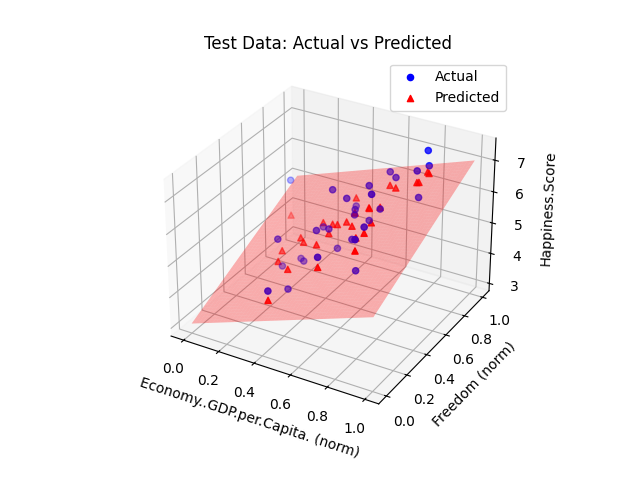

In [10]:
model_scratch = GradientDescentRegressor(learning_rate=0.01, max_iterations=10000, tolerance=1e-6)
model_scratch.fit(X_train, Y_train)
predictions_scratch = model_scratch.predict(X_test)
mae_scratch = mean_absolute_error(Y_test, predictions_scratch)
mse_scratch = mean_squared_error(Y_test, predictions_scratch)
print(f'Gradient Descent from Scratch - Mean Absolute Error: {mae_scratch:.4f}')
print(f'Gradient Descent from Scratch - Mean Squared Error: {mse_scratch:.4f}')

x1_range_scratch = np.linspace(df[features_names[0] + "_normalized"].min(), df[features_names[0] + "_normalized"].max(), 50)
x2_range_scratch = np.linspace(df[features_names[1] + "_normalized"].min(), df[features_names[1] + "_normalized"].max(), 50)
x1_grid_scratch, x2_grid_scratch = np.meshgrid(x1_range_scratch, x2_range_scratch)
y_grid_scratch = model_scratch.w0 + model_scratch.w1 * x1_grid_scratch + model_scratch.w2 * x2_grid_scratch

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_test[features_names[0] + "_normalized"], X_test[features_names[1] + "_normalized"], Y_test, c='b', marker='o', label='Actual')
ax.scatter(X_test[features_names[0] + "_normalized"], X_test[features_names[1] + "_normalized"], predictions_scratch, c='r', marker='^', label='Predicted')
ax.plot_surface(x1_grid, x2_grid, y_grid, alpha=0.3, color='red')
ax.set_xlabel(f'{features_names[0]} (norm)')
ax.set_ylabel(f'{features_names[1]} (norm)')
ax.set_zlabel(target_name)
ax.set_title('Test Data: Actual vs Predicted')
ax.legend()
plt.show()

We can see our model performs better then the one we trained using `sklearn`. This is because the the `sklearn` model has by default only 1000 max_iter, we can see that in the documentation [here](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.SGDRegressor.html).